# PatchTST Model for Microsoft Stock Forecasting

## Purpose

This notebook trains and evaluates a PatchTST transformer model for one-step-ahead Microsoft (`MSFT`) adjusted Close forecasting. Each prediction follows the same project target definition: use the previous 60 trading days to forecast the next trading day's adjusted Close.

PatchTST is included to compare a transformer-style time-series model with the recurrent LSTM and GRU models from Notebook 02.

## Link to the project workflow

This is the Modelling stage for the transformer model. The notebook keeps the same data period, split boundaries, target dates, and evaluation style as the earlier notebooks so its outputs can be compared in Notebook 04.


## Relationship to Notebook 01 and Notebook 02

Notebook 01 defines the project data period, creates the 70/15/15 chronological split, and saves aligned validation and test target-date arrays. Notebook 02 uses 60-day OHLCV windows for LSTM and GRU one-step-ahead forecasting.

Notebook 03 independently downloads the same MSFT data in NeuralForecast format, then validates all raw split dates and exported prediction dates against Notebook 01. This keeps PatchTST outputs ready for Notebook 04 without editing or running notebooks 01, 02, or 04.


## PatchTST architecture background

PatchTST converts a time series into temporal patches and applies a transformer encoder over those patches. At a high level, patching groups neighbouring time steps together, so the model can learn from short subsequences rather than treating every trading day as a fully separate token.

This differs from LSTM and GRU models, which read the sequence step by step through recurrent hidden states. PatchTST can be useful when longer sequence patterns matter, but it is not assumed to be automatically better for stock prices.

For this project the PatchTST context length is 60 trading days. The notebook first attempts to use historical Open, High, Low, and Volume values as exogenous variables. If the installed NeuralForecast PatchTST rejects historical exogenous variables, the notebook falls back to a Close-only univariate PatchTST and records that limitation.


## Data formatting for NeuralForecast

The date-based dataframe uses the NeuralForecast column names:

- `unique_id = "MSFT"`
- `ds = real trading date`
- `y = adjusted Close`, represented by `Close` because `yfinance` is downloaded with `auto_adjust=True`

MSFT trading dates are irregular because of market holidays. For NeuralForecast frequency handling, this notebook uses an internal integer `trading_step` as the modelling time index, saves `patchtst_date_index_mapping.csv`, and maps all exported prediction CSVs back to real trading dates in `ds`.


In [1]:
from pathlib import Path
import inspect
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yfinance as yf
from IPython.display import Markdown, display
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

TICKER = "MSFT"
START_DATE = "2010-01-01"
END_DATE = "2026-04-24"
PROJECT_END_DATE = "2026-04-23"
PROJECT_PERIOD_LABEL = f"{START_DATE} to {PROJECT_END_DATE}"

FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
HIST_EXOG_COLS = ["Open", "High", "Low", "Volume"]
TARGET_COL = "Close"
WINDOW_SIZE = 60
UNIQUE_ID = "MSFT"

FORECASTING_PROTOCOL = "rolling_one_step_ahead"
TRAINING_PROTOCOL = "selected_on_train_to_val_then_refit_train_val_for_test"

DATA_DIR = Path("../data")
TABLES_DIR = Path("../outputs/tables")
PLOTS_DIR = Path("../outputs/plots")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")
print(f"Ticker: {TICKER}")
print(f"Project period: {PROJECT_PERIOD_LABEL}")
print(f"yfinance request: start={START_DATE}, end={END_DATE} (exclusive end)")
print(f"forecasting_protocol: {FORECASTING_PROTOCOL}")
print(f"training_protocol: {TRAINING_PROTOCOL}")


Libraries imported successfully.
Ticker: MSFT
Project period: 2010-01-01 to 2026-04-23
yfinance request: start=2010-01-01, end=2026-04-24 (exclusive end)
forecasting_protocol: rolling_one_step_ahead
training_protocol: selected_on_train_to_val_then_refit_train_val_for_test


## Project date constants and yfinance download

The project period is **2010-01-01 to 2026-04-23**. The yfinance `end` argument is exclusive, so this notebook requests `END_DATE = "2026-04-24"` to include the final project trading day, **2026-04-23**.

The first requested calendar date, 2010-01-01, was not a trading day. The first actual trading row is therefore expected to be **2010-01-04**.


In [2]:
raw_df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw_df.empty:
    raise ValueError("No data was downloaded from yfinance. Check network access or ticker/date settings.")

if isinstance(raw_df.columns, pd.MultiIndex):
    if set(FEATURE_COLS).issubset(raw_df.columns.get_level_values(0)):
        raw_df.columns = raw_df.columns.get_level_values(0)
    elif set(FEATURE_COLS).issubset(raw_df.columns.get_level_values(1)):
        raw_df.columns = raw_df.columns.get_level_values(1)
    else:
        raise ValueError(f"Could not find required OHLCV columns in downloaded data: {raw_df.columns}")

raw_df.columns.name = None
missing_cols = set(FEATURE_COLS) - set(raw_df.columns)
if missing_cols:
    raise ValueError(f"Downloaded data is missing required columns: {sorted(missing_cols)}")

df = raw_df[FEATURE_COLS].copy()
df.index = pd.to_datetime(df.index).tz_localize(None)
df = df.sort_index()
df = df[~df.index.duplicated(keep="first")]
df = df.dropna(subset=FEATURE_COLS)

expected_first_date = pd.Timestamp("2010-01-04")
expected_last_date = pd.Timestamp(PROJECT_END_DATE)

assert len(df) == 4101, f"Expected 4101 downloaded trading rows, found {len(df)}."
assert df.index[0] == expected_first_date, f"Expected first trading date {expected_first_date.date()}, found {df.index[0].date()}."
assert df.index[-1] == expected_last_date, f"Expected last trading date {expected_last_date.date()}, found {df.index[-1].date()}."
assert not df[FEATURE_COLS].isna().any().any(), "Missing values remain in required OHLCV columns."
assert df.index.is_monotonic_increasing, "Downloaded dataframe is not chronological."

print(f"Downloaded data shape: {df.shape}")
print(f"Trading date range: {df.index[0].date()} to {df.index[-1].date()}")
print("No missing values remain in required OHLCV columns.")
display(df.head())


Downloaded data shape: (4101, 5)
Trading date range: 2010-01-04 to 2026-04-23
No missing values remain in required OHLCV columns.


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,22.831324,23.189228,22.808954,23.077383,38409100
2010-01-05,23.002816,23.189225,22.846232,23.084835,49749600
2010-01-06,23.025182,23.174309,22.756754,22.943163,58182400
2010-01-07,22.838774,22.890970,22.510696,22.704561,50559700
2010-01-08,22.577805,23.025184,22.547979,22.861145,51197400


## Train-validation-test alignment

Notebook 01 uses a chronological 70/15/15 raw split. With 4101 downloaded trading rows, that produces:

- raw train: 2870 rows, 2010-01-04 to 2021-05-27
- raw validation: 615 rows, 2021-05-28 to 2023-11-06
- raw test: 616 rows, 2023-11-07 to 2026-04-23

PatchTST rolling cross-validation works from the raw series. Notebook 01's `train_dates` are shorter because the first 60 training rows are input history before the first train target. Validation and test target dates equal the raw validation and test dates.


In [3]:
def as_datetime_index(date_array):
    return pd.DatetimeIndex(pd.to_datetime(date_array)).tz_localize(None)


def date_range_text(dates):
    dates = as_datetime_index(dates)
    return f"{dates[0].date()} to {dates[-1].date()}"

train_dates = np.load(DATA_DIR / "train_dates.npy")
val_dates = np.load(DATA_DIR / "val_dates.npy")
test_dates = np.load(DATA_DIR / "test_dates.npy")

train_dates_idx = as_datetime_index(train_dates)
val_dates_idx = as_datetime_index(val_dates)
test_dates_idx = as_datetime_index(test_dates)

assert len(train_dates_idx) == 2810, f"Expected train_dates length 2810, found {len(train_dates_idx)}."
assert len(val_dates_idx) == 615, f"Expected val_dates length 615, found {len(val_dates_idx)}."
assert len(test_dates_idx) == 616, f"Expected test_dates length 616, found {len(test_dates_idx)}."
assert val_dates_idx[0] == pd.Timestamp("2021-05-28") and val_dates_idx[-1] == pd.Timestamp("2023-11-06")
assert test_dates_idx[0] == pd.Timestamp("2023-11-07") and test_dates_idx[-1] == pd.Timestamp("2026-04-23")

n_rows = len(df)
train_end = int(n_rows * 0.70)
val_end = int(n_rows * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

assert len(train_df) == 2870
assert len(val_df) == 615
assert len(test_df) == 616
assert train_df.index[0] == pd.Timestamp("2010-01-04") and train_df.index[-1] == pd.Timestamp("2021-05-27")
assert val_df.index[0] == pd.Timestamp("2021-05-28") and val_df.index[-1] == pd.Timestamp("2023-11-06")
assert test_df.index[0] == pd.Timestamp("2023-11-07") and test_df.index[-1] == pd.Timestamp("2026-04-23")

np.testing.assert_array_equal(val_df.index.values.astype("datetime64[D]"), val_dates_idx.values.astype("datetime64[D]"))
np.testing.assert_array_equal(test_df.index.values.astype("datetime64[D]"), test_dates_idx.values.astype("datetime64[D]"))

split_summary = pd.DataFrame([
    {"Split": "Train", "Raw rows": len(train_df), "Raw start": train_df.index[0].date(), "Raw end": train_df.index[-1].date(), "Notebook 01 target rows": len(train_dates_idx), "Notebook 01 target range": date_range_text(train_dates_idx)},
    {"Split": "Validation", "Raw rows": len(val_df), "Raw start": val_df.index[0].date(), "Raw end": val_df.index[-1].date(), "Notebook 01 target rows": len(val_dates_idx), "Notebook 01 target range": date_range_text(val_dates_idx)},
    {"Split": "Test", "Raw rows": len(test_df), "Raw start": test_df.index[0].date(), "Raw end": test_df.index[-1].date(), "Notebook 01 target rows": len(test_dates_idx), "Notebook 01 target range": date_range_text(test_dates_idx)},
])

print("Chronological split row counts and alignment checks passed.")
display(split_summary)


Chronological split row counts and alignment checks passed.


,Split,Raw rows,Raw start,Raw end,Notebook 01 target rows,Notebook 01 target range
0,Train,2870,2010-01-04,2021-05-27,2810,2010-03-31 to 2021-05-27
1,Validation,615,2021-05-28,2023-11-06,615,2021-05-28 to 2023-11-06
2,Test,616,2023-11-07,2026-04-23,616,2023-11-07 to 2026-04-23


## PatchTST input design

The preferred PatchTST design is:

- target `y`: adjusted Close
- historical exogenous variables: Open, High, Low, Volume

This keeps PatchTST closer to the original OHLCV feature set used by LSTM and GRU. However, NeuralForecast versions differ in their PatchTST exogenous support. This notebook tries OHLCV historical exogenous inputs first and safely falls back to Close-only if the interface or runtime rejects them.

If fallback is used, PatchTST is not directly feature-equivalent to LSTM/GRU because LSTM/GRU use OHLCV windows while PatchTST uses only historical Close. In that case, the comparison is not a perfectly controlled architecture-only comparison.


In [4]:
# Date-based dataframe requested for project transparency.
nf_date_df = df.reset_index(names="ds")
nf_date_df["unique_id"] = UNIQUE_ID
nf_date_df["y"] = nf_date_df[TARGET_COL]
nf_date_df = nf_date_df[["unique_id", "ds", "y", "Open", "High", "Low", "Volume"]]

# Internal regular trading-step dataframe used by NeuralForecast.
step_df = nf_date_df.copy()
step_df["trading_step"] = np.arange(len(step_df), dtype=np.int64)
step_df["real_ds"] = step_df["ds"]
step_df["ds"] = step_df["trading_step"]
step_df = step_df[["unique_id", "ds", "y", "Open", "High", "Low", "Volume", "real_ds", "trading_step"]]

step_to_date = step_df[["trading_step", "real_ds"]].copy().rename(columns={"real_ds": "ds"})
step_to_date["split"] = np.select(
    [step_to_date["trading_step"] < train_end, step_to_date["trading_step"] < val_end],
    ["Train", "Validation"],
    default="Test",
)
step_to_date["ds"] = pd.to_datetime(step_to_date["ds"]).dt.strftime("%Y-%m-%d")

mapping_path = TABLES_DIR / "patchtst_date_index_mapping.csv"
step_to_date.to_csv(mapping_path, index=False)

train_val_model_df = step_df.iloc[:val_end].drop(columns=["real_ds", "trading_step"]).copy()
all_model_df = step_df.drop(columns=["real_ds", "trading_step"]).copy()

print("Date-based NeuralForecast dataframe:")
display(nf_date_df.head())
print("Internal trading-step dataframe for NeuralForecast:")
display(step_df.head())
print(f"Saved trading-step to real-date mapping to {mapping_path}")


Date-based NeuralForecast dataframe:


,unique_id,ds,y,Open,High,Low,Volume
0,MSFT,2010-01-04,23.077383,22.831324,23.189228,22.808954,38409100
1,MSFT,2010-01-05,23.084835,23.002816,23.189225,22.846232,49749600
2,MSFT,2010-01-06,22.943163,23.025182,23.174309,22.756754,58182400
3,MSFT,2010-01-07,22.704561,22.838774,22.890970,22.510696,50559700
4,MSFT,2010-01-08,22.861145,22.577805,23.025184,22.547979,51197400


Internal trading-step dataframe for NeuralForecast:


,unique_id,ds,y,Open,High,Low,Volume,real_ds,trading_step
0,MSFT,0,23.077383,22.831324,23.189228,22.808954,38409100,2010-01-04,0
1,MSFT,1,23.084835,23.002816,23.189225,22.846232,49749600,2010-01-05,1
2,MSFT,2,22.943163,23.025182,23.174309,22.756754,58182400,2010-01-06,2
3,MSFT,3,22.704561,22.838774,22.890970,22.510696,50559700,2010-01-07,3
4,MSFT,4,22.861145,22.577805,23.025184,22.547979,51197400,2010-01-08,4


Saved trading-step to real-date mapping to ../outputs/tables/patchtst_date_index_mapping.csv


## Rolling one-step-ahead forecasting protocol

This notebook uses `forecasting_protocol = "rolling_one_step_ahead"`. PatchTST is configured with `h=1` and `input_size=60`, then NeuralForecast `cross_validation` is used with `step_size=1` and the validation or test horizon as `test_size`.

For validation tuning, the dataframe contains train+validation rows and the validation period is the cross-validation tail. For final testing, the dataframe contains train+validation+test rows and the test period is the cross-validation tail. In both cases, NeuralForecast trains before the tail and produces one-step-ahead predictions for each tail row. Later test targets may use previous observed test closes as historical context, which is the same rolling one-step setting as the naive baseline: each prediction at date `t` may use information up to `t-1`, but not the target value at `t`.

The notebook inspects the returned `cutoff` convention rather than assuming it blindly. In this environment, the expected convention is `cutoff = target_step - 1` for `h=1`, meaning the input history ends strictly before the target date.


## Hyperparameter configuration / light tuning

PatchTST tuning is intentionally lightweight for CA2 runtime reasons. Each candidate is evaluated with rolling one-step validation predictions. The selected configuration is the one with the lowest validation RMSE in dollar space; ties are broken by validation MAE and then by candidate order.


In [5]:
candidate_configs = [
    {"CandidateName": "A", "input_size": 60, "patch_len": 12, "stride": 12, "hidden_size": 64, "n_heads": 4, "learning_rate": 1e-3, "max_steps": 500, "batch_size": 64},
    {"CandidateName": "B", "input_size": 60, "patch_len": 10, "stride": 10, "hidden_size": 64, "n_heads": 4, "learning_rate": 1e-3, "max_steps": 500, "batch_size": 64},
    {"CandidateName": "C", "input_size": 60, "patch_len": 12, "stride": 6, "hidden_size": 64, "n_heads": 4, "learning_rate": 5e-4, "max_steps": 500, "batch_size": 64},
]

print("PatchTST candidate configurations:")
display(pd.DataFrame(candidate_configs))


PatchTST candidate configurations:


,CandidateName,input_size,patch_len,stride,hidden_size,n_heads,learning_rate,max_steps,batch_size
0,A,60,12,12,64,4,0.0010,500,64
1,B,60,10,10,64,4,0.0010,500,64
2,C,60,12,6,64,4,0.0005,500,64


## Evaluation metrics

The notebook reports dollar-space MSE, RMSE, MAE, MAPE, R2, and `Directional_Accuracy`.

`Directional_Accuracy` compares the sign of the actual one-day move with the sign of the predicted one-day move, both relative to the previous known adjusted Close. For the naive baseline, directional accuracy is saved as `NaN` because a last-close forecast predicts no movement, so direction is not a meaningful signal for that baseline.


In [6]:
def calculate_metrics(y_true, y_pred, previous_close, compute_direction=True):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    previous_close = np.asarray(previous_close, dtype=float).reshape(-1)

    assert len(y_true) == len(y_pred) == len(previous_close), "Metric arrays must have matching lengths."
    assert np.isfinite(y_true).all() and np.isfinite(y_pred).all(), "Metric arrays contain non-finite values."

    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    nonzero_mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100) if np.any(nonzero_mask) else np.nan
    r2 = float(r2_score(y_true, y_pred))

    if compute_direction:
        actual_direction = np.sign(y_true - previous_close)
        predicted_direction = np.sign(y_pred - previous_close)
        direction_mask = actual_direction != 0
        directional_accuracy = float(np.mean(actual_direction[direction_mask] == predicted_direction[direction_mask]) * 100) if np.any(direction_mask) else np.nan
    else:
        directional_accuracy = np.nan

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2, "Directional_Accuracy": directional_accuracy}


def actual_values_for_dates(date_index):
    return df.loc[pd.DatetimeIndex(date_index), TARGET_COL].to_numpy(dtype=float)


def previous_close_for_dates(date_index):
    previous = df[TARGET_COL].shift(1).loc[pd.DatetimeIndex(date_index)]
    if previous.isna().any():
        raise ValueError("Previous_Close contains NaN values for requested dates.")
    return previous.to_numpy(dtype=float)

actual_val = actual_values_for_dates(val_dates_idx)
actual_test = actual_values_for_dates(test_dates_idx)
previous_close_val = previous_close_for_dates(val_dates_idx)
previous_close_test = previous_close_for_dates(test_dates_idx)
naive_val = previous_close_val.copy()
naive_test = previous_close_test.copy()

naive_val_metrics = calculate_metrics(actual_val, naive_val, previous_close_val, compute_direction=False)
naive_test_metrics = calculate_metrics(actual_test, naive_test, previous_close_test, compute_direction=False)

print("Naive baseline metrics prepared.")
display(pd.DataFrame([
    {"Model": "Naive Baseline", "Dataset": "Validation Set", **naive_val_metrics},
    {"Model": "Naive Baseline", "Dataset": "Test Set", **naive_test_metrics},
]))


Naive baseline metrics prepared.


,Model,Dataset,MSE,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,Naive Baseline,Validation Set,24.548779,4.954672,3.743970,1.359295,0.977924,NaN
1,Naive Baseline,Test Set,39.608228,6.293507,4.390737,1.033303,0.981276,NaN


In [7]:
def make_patchtst_model(config, hist_exog_list, alias="PatchTST"):
    kwargs = {
        "h": 1,
        "input_size": config["input_size"],
        "patch_len": config["patch_len"],
        "stride": config["stride"],
        "hidden_size": config["hidden_size"],
        "n_heads": config["n_heads"],
        "learning_rate": config["learning_rate"],
        "max_steps": config["max_steps"],
        "batch_size": config["batch_size"],
        "scaler_type": "robust",
        "random_seed": RANDOM_SEED,
        "alias": alias,
        "enable_checkpointing": False,
        "logger": False,
        "enable_progress_bar": False,
        "enable_model_summary": False,
        "accelerator": "cpu",
    }
    if hist_exog_list is not None:
        kwargs["hist_exog_list"] = hist_exog_list
    return PatchTST(**kwargs)


def rolling_one_step_cv(model_frame, config, horizon_length, hist_exog_list):
    model = make_patchtst_model(config, hist_exog_list=hist_exog_list)
    nf = NeuralForecast(models=[model], freq=1)
    cv_df = nf.cross_validation(
        df=model_frame,
        n_windows=None,
        test_size=horizon_length,
        val_size=0,
        step_size=1,
        h=1,
        refit=False,
        verbose=False,
    )
    cv_df = cv_df.sort_values(["unique_id", "ds", "cutoff"]).reset_index(drop=True)
    if "PatchTST" not in cv_df.columns:
        model_cols = [c for c in cv_df.columns if c not in ["unique_id", "ds", "cutoff", "y"]]
        if len(model_cols) != 1:
            raise ValueError(f"Could not identify PatchTST forecast column. Columns: {cv_df.columns.tolist()}")
        cv_df = cv_df.rename(columns={model_cols[0]: "PatchTST"})
    return cv_df


def inspect_and_validate_cutoff_convention(cv_df, expected_steps, config, label, hist_exog_list):
    target_steps = cv_df["ds"].to_numpy(dtype=np.int64)
    cutoff_steps = cv_df["cutoff"].to_numpy(dtype=np.int64)
    expected_steps = np.asarray(expected_steps, dtype=np.int64)

    np.testing.assert_array_equal(target_steps, expected_steps, err_msg=f"{label}: forecast target steps do not match expected horizon.")
    assert cv_df["PatchTST"].notna().all(), f"{label}: PatchTST predictions contain NaN values."

    cutoff_diffs = target_steps - cutoff_steps
    unique_diffs = sorted(pd.Series(cutoff_diffs).unique().tolist())
    convention = f"NeuralForecast returned target_step - cutoff_step values: {unique_diffs}."

    if np.all(cutoff_diffs == 1):
        convention += " For this h=1 run, cutoff_step is the final observed trading step before the target step."
    else:
        convention += " The cutoff convention differs from the expected h=1 t-1 convention, so leakage checks use the returned cutoff as the latest available historical step."

    assert np.all(cutoff_steps < target_steps), f"{label}: at least one cutoff is not strictly before its target step. {convention}"

    input_end_steps = cutoff_steps
    input_start_steps = input_end_steps - config["input_size"] + 1
    assert np.all(input_start_steps >= 0), f"{label}: at least one expected input window starts before the available series."
    assert np.all(input_end_steps < target_steps), f"{label}: expected input window does not end strictly before target step."
    assert not np.any((target_steps >= input_start_steps) & (target_steps <= input_end_steps)), f"{label}: target step appears inside its expected input window."

    if hist_exog_list is not None:
        assert np.all(input_end_steps < target_steps), f"{label}: historical exogenous window includes target-date step."
        exog_note = "Historical exogenous variables are limited to the same strictly pre-target input window."
    else:
        exog_note = "No historical exogenous variables were used in this run."

    leakage_summary = {
        "Dataset": label,
        "forecasting_protocol": FORECASTING_PROTOCOL,
        "target_step_min": int(target_steps.min()),
        "target_step_max": int(target_steps.max()),
        "cutoff_step_min": int(cutoff_steps.min()),
        "cutoff_step_max": int(cutoff_steps.max()),
        "unique_target_minus_cutoff": unique_diffs,
        "input_window_start_min": int(input_start_steps.min()),
        "input_window_end_max": int(input_end_steps.max()),
        "target_inside_expected_input_window": bool(np.any((target_steps >= input_start_steps) & (target_steps <= input_end_steps))),
        "cutoff_convention_note": convention,
        "exogenous_leakage_note": exog_note,
    }
    return leakage_summary


def make_prediction_frame(real_dates, actual, previous_close, naive, patchtst_pred):
    frame = pd.DataFrame({
        "ds": pd.DatetimeIndex(real_dates).strftime("%Y-%m-%d"),
        "Actual": np.asarray(actual, dtype=float).reshape(-1),
        "y": np.asarray(actual, dtype=float).reshape(-1),
        "Previous_Close": np.asarray(previous_close, dtype=float).reshape(-1),
        "Naive": np.asarray(naive, dtype=float).reshape(-1),
        "PatchTST": np.asarray(patchtst_pred, dtype=float).reshape(-1),
    })
    frame["Naive_Error"] = frame["Naive"] - frame["Actual"]
    frame["PatchTST_Error"] = frame["PatchTST"] - frame["Actual"]
    assert frame["ds"].str.match(r"\d{4}-\d{2}-\d{2}").all(), "Prediction ds column must contain real date strings."
    assert frame["PatchTST"].notna().all(), "PatchTST predictions contain NaN values."
    assert pd.to_datetime(frame["ds"]).is_monotonic_increasing, "Prediction dates are not strictly increasing."
    return frame


def run_patchtst_workflow(hist_exog_list, input_mode, input_mode_note):
    tuning_rows = []
    validation_predictions_by_candidate = {}
    validation_leakage_by_candidate = {}
    expected_val_steps = np.arange(train_end, val_end, dtype=np.int64)

    for candidate_order, config in enumerate(candidate_configs):
        print(f"Training PatchTST candidate {config['CandidateName']} in mode: {input_mode}")
        val_cv = rolling_one_step_cv(
            model_frame=train_val_model_df,
            config=config,
            horizon_length=len(val_df),
            hist_exog_list=hist_exog_list,
        )
        leakage_summary = inspect_and_validate_cutoff_convention(
            val_cv,
            expected_steps=expected_val_steps,
            config=config,
            label=f"Validation Candidate {config['CandidateName']}",
            hist_exog_list=hist_exog_list,
        )
        val_pred = val_cv["PatchTST"].to_numpy(dtype=float)
        val_metrics = calculate_metrics(actual_val, val_pred, previous_close_val, compute_direction=True)

        row = {
            "ModelFamily": "PatchTST",
            "CandidateName": config["CandidateName"],
            "PATCHTST_INPUT_MODE": input_mode,
            "forecasting_protocol": FORECASTING_PROTOCOL,
            "training_protocol": TRAINING_PROTOCOL,
            "input_mode_note": input_mode_note,
            "candidate_order": candidate_order,
            "input_size": config["input_size"],
            "patch_len": config["patch_len"],
            "stride": config["stride"],
            "hidden_size": config["hidden_size"],
            "n_heads": config["n_heads"],
            "learning_rate": config["learning_rate"],
            "max_steps": config["max_steps"],
            "batch_size": config["batch_size"],
            "val_MSE": val_metrics["MSE"],
            "val_RMSE": val_metrics["RMSE"],
            "val_MAE": val_metrics["MAE"],
            "val_MAPE": val_metrics["MAPE"],
            "val_R2": val_metrics["R2"],
            "val_Directional_Accuracy": val_metrics["Directional_Accuracy"],
            "is_selected_final": False,
        }
        tuning_rows.append(row)
        validation_predictions_by_candidate[config["CandidateName"]] = val_pred
        validation_leakage_by_candidate[config["CandidateName"]] = leakage_summary
        print(
            f"Candidate {config['CandidateName']} validation RMSE={val_metrics['RMSE']:.4f}, "
            f"MAE={val_metrics['MAE']:.4f}, Directional_Accuracy={val_metrics['Directional_Accuracy']:.2f}%"
        )

    tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_RMSE", "val_MAE", "candidate_order"]).reset_index(drop=True)
    selected_name = tuning_df.iloc[0]["CandidateName"]
    for row in tuning_rows:
        row["is_selected_final"] = row["CandidateName"] == selected_name

    selected_config = next(config for config in candidate_configs if config["CandidateName"] == selected_name)
    selected_val_pred = validation_predictions_by_candidate[selected_name]
    selected_val_leakage = validation_leakage_by_candidate[selected_name]

    print(f"Selected PatchTST candidate: {selected_name}")
    print("Refitting selected candidate through NeuralForecast cross_validation on train+validation history for test tail predictions.")

    expected_test_steps = np.arange(val_end, n_rows, dtype=np.int64)
    test_cv = rolling_one_step_cv(
        model_frame=all_model_df,
        config=selected_config,
        horizon_length=len(test_df),
        hist_exog_list=hist_exog_list,
    )
    selected_test_leakage = inspect_and_validate_cutoff_convention(
        test_cv,
        expected_steps=expected_test_steps,
        config=selected_config,
        label="Test Selected Candidate",
        hist_exog_list=hist_exog_list,
    )
    selected_test_pred = test_cv["PatchTST"].to_numpy(dtype=float)

    return pd.DataFrame(tuning_rows), selected_config, selected_val_pred, selected_test_pred, selected_val_leakage, selected_test_leakage

patchtst_signature = inspect.signature(PatchTST.__init__)
if "hist_exog_list" not in patchtst_signature.parameters:
    raise RuntimeError("Installed NeuralForecast PatchTST does not expose hist_exog_list.")


In [8]:
try:
    PATCHTST_INPUT_MODE = "OHLCV historical exogenous"
    input_mode_note = "OHLCV historical exogenous inputs supported and used."
    tuning_results_df, selected_config, patchtst_val_pred, patchtst_test_pred, val_leakage_summary, test_leakage_summary = run_patchtst_workflow(
        hist_exog_list=HIST_EXOG_COLS,
        input_mode=PATCHTST_INPUT_MODE,
        input_mode_note=input_mode_note,
    )
except Exception as exog_error:
    PATCHTST_INPUT_MODE = "Close-only univariate"
    input_mode_note = f"OHLCV historical exogenous path failed; fell back to Close-only. Reason: {type(exog_error).__name__}: {str(exog_error)[:500]}"
    print(input_mode_note)
    tuning_results_df, selected_config, patchtst_val_pred, patchtst_test_pred, val_leakage_summary, test_leakage_summary = run_patchtst_workflow(
        hist_exog_list=None,
        input_mode=PATCHTST_INPUT_MODE,
        input_mode_note=input_mode_note,
    )

tuning_columns = [
    "ModelFamily", "CandidateName", "PATCHTST_INPUT_MODE", "forecasting_protocol", "training_protocol", "input_mode_note",
    "input_size", "patch_len", "stride", "hidden_size", "n_heads", "learning_rate", "max_steps", "batch_size",
    "val_MSE", "val_RMSE", "val_MAE", "val_MAPE", "val_R2", "val_Directional_Accuracy", "is_selected_final",
]

tuning_results_df = tuning_results_df[tuning_columns]
tuning_results_path = TABLES_DIR / "patchtst_tuning_results.csv"
tuning_results_df.to_csv(tuning_results_path, index=False)

print(f"PATCHTST_INPUT_MODE: {PATCHTST_INPUT_MODE}")
print(f"forecasting_protocol: {FORECASTING_PROTOCOL}")
print(f"training_protocol: {TRAINING_PROTOCOL}")
print(f"input_mode_note: {input_mode_note}")
print("Validation leakage summary for selected candidate:")
display(pd.DataFrame([val_leakage_summary]))
print("Test leakage summary for selected candidate:")
display(pd.DataFrame([test_leakage_summary]))
print(f"Saved tuning results to {tuning_results_path}")
display(tuning_results_df)


Seed set to 42


Seed set to 42


Training PatchTST candidate A in mode: OHLCV historical exogenous
OHLCV historical exogenous path failed; fell back to Close-only. Reason: Exception: PatchTST does not support historical exogenous variables.
Training PatchTST candidate A in mode: Close-only univariate


GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


...

,Dataset,forecasting_protocol,target_step_min,target_step_max,cutoff_step_min,cutoff_step_max,unique_target_minus_cutoff,input_window_start_min,input_window_end_max,target_inside_expected_input_window,cutoff_convention_note,exogenous_leakage_note
0,Validation Candidate C,rolling_one_step_ahead,2870,3484,2869,3483,[1],2810,3483,False,NeuralForecast returned target_step - cutoff_s...,No historical exogenous variables were used in...


Test leakage summary for selected candidate:


,Dataset,forecasting_protocol,target_step_min,target_step_max,cutoff_step_min,cutoff_step_max,unique_target_minus_cutoff,input_window_start_min,input_window_end_max,target_inside_expected_input_window,cutoff_convention_note,exogenous_leakage_note
0,Test Selected Candidate,rolling_one_step_ahead,3485,4100,3484,4099,[1],3425,4099,False,NeuralForecast returned target_step - cutoff_s...,No historical exogenous variables were used in...


Saved tuning results to ../outputs/tables/patchtst_tuning_results.csv


,ModelFamily,CandidateName,PATCHTST_INPUT_MODE,forecasting_protocol,training_protocol,input_mode_note,input_size,patch_len,stride,hidden_size,...,learning_rate,max_steps,batch_size,val_MSE,val_RMSE,val_MAE,val_MAPE,val_R2,val_Directional_Accuracy,is_selected_final
0,PatchTST,A,Close-only univariate,rolling_one_step_ahead,selected_on_train_to_val_then_refit_train_val_...,OHLCV historical exogenous path failed; fell b...,60,12,12,64,...,0.0010,500,64,27.996668,5.291188,3.986224,1.452733,0.974823,48.859935,False
1,PatchTST,B,Close-only univariate,rolling_one_step_ahead,selected_on_train_to_val_then_refit_train_val_...,OHLCV historical exogenous path failed; fell b...,60,10,10,64,...,0.0010,500,64,28.798862,5.366457,4.061863,1.480766,0.974102,47.557003,False
2,PatchTST,C,Close-only univariate,rolling_one_step_ahead,selected_on_train_to_val_then_refit_train_val_...,OHLCV historical exogenous path failed; fell b...,60,12,6,64,...,0.0005,500,64,26.514461,5.149219,3.889027,1.414452,0.976156,49.511401,True


## Leakage and alignment checks

For every PatchTST prediction at date `t`, the returned NeuralForecast `cutoff` is inspected. In this rolling one-step-ahead run, the cutoff is expected to be the trading step immediately before the target step. The leakage checks verify that the implied 60-day input window ends before `t` and does not contain the target step.

If OHLCV historical exogenous variables are used, the same cutoff check ensures same-day target Open, High, Low, and Volume are not in the historical input window. If the notebook falls back to Close-only, no exogenous variables are used.


## Validation and test prediction generation

The selected candidate's validation predictions come from rolling one-step-ahead cross-validation over the validation tail. The selected candidate's test predictions come from the same selected configuration evaluated over the test tail after validation-based model selection. Test rows are not used for tuning; in rolling one-step evaluation, prior observed test values may be used only as historical context for later test dates.

All exported prediction files use real trading dates in `ds`. The internal integer `trading_step` exists only for NeuralForecast frequency handling and is saved separately in `patchtst_date_index_mapping.csv`.


In [9]:
patchtst_val_predictions_df = make_prediction_frame(
    real_dates=val_dates_idx,
    actual=actual_val,
    previous_close=previous_close_val,
    naive=naive_val,
    patchtst_pred=patchtst_val_pred,
)
patchtst_test_predictions_df = make_prediction_frame(
    real_dates=test_dates_idx,
    actual=actual_test,
    previous_close=previous_close_test,
    naive=naive_test,
    patchtst_pred=patchtst_test_pred,
)

np.testing.assert_array_equal(pd.to_datetime(patchtst_val_predictions_df["ds"]).values.astype("datetime64[D]"), val_dates_idx.values.astype("datetime64[D]"))
np.testing.assert_array_equal(pd.to_datetime(patchtst_test_predictions_df["ds"]).values.astype("datetime64[D]"), test_dates_idx.values.astype("datetime64[D]"))
assert len(patchtst_val_predictions_df) == 615
assert len(patchtst_test_predictions_df) == 616
assert patchtst_val_predictions_df["PatchTST"].notna().all()
assert patchtst_test_predictions_df["PatchTST"].notna().all()
assert pd.to_datetime(patchtst_val_predictions_df["ds"]).is_monotonic_increasing
assert pd.to_datetime(patchtst_test_predictions_df["ds"]).is_monotonic_increasing

patchtst_val_predictions_path = TABLES_DIR / "patchtst_val_predictions.csv"
patchtst_test_predictions_path = TABLES_DIR / "patchtst_test_predictions.csv"
patchtst_predictions_path = TABLES_DIR / "patchtst_predictions.csv"

patchtst_val_predictions_df.to_csv(patchtst_val_predictions_path, index=False)
patchtst_test_predictions_df.to_csv(patchtst_test_predictions_path, index=False)
patchtst_test_predictions_df.to_csv(patchtst_predictions_path, index=False)

print(f"Saved validation predictions to {patchtst_val_predictions_path}")
print(f"Saved test predictions to {patchtst_test_predictions_path}")
print(f"Saved backward-compatible test predictions to {patchtst_predictions_path}")
print("First 5 validation prediction rows:")
display(patchtst_val_predictions_df.head(5))
print("Last 5 validation prediction rows:")
display(patchtst_val_predictions_df.tail(5))
print("First 5 test prediction rows:")
display(patchtst_test_predictions_df.head(5))
print("Last 5 test prediction rows:")
display(patchtst_test_predictions_df.tail(5))


Saved validation predictions to ../outputs/tables/patchtst_val_predictions.csv
Saved test predictions to ../outputs/tables/patchtst_test_predictions.csv
Saved backward-compatible test predictions to ../outputs/tables/patchtst_predictions.csv
First 5 validation prediction rows:


,ds,Actual,y,Previous_Close,Naive,PatchTST,Naive_Error,PatchTST_Error
0,2021-05-28,240.136078,240.136078,239.780212,239.780212,240.037811,-0.355865,-0.098267
1,2021-06-01,237.943207,237.943207,240.136078,240.136078,241.032928,2.192871,3.089722
2,2021-06-02,237.847031,237.847031,237.943207,237.943207,237.764389,0.096176,-0.082642
3,2021-06-03,236.317825,236.317825,237.847031,237.847031,237.659119,1.529205,1.341293
4,2021-06-04,241.203598,241.203598,236.317825,236.317825,235.598083,-4.885773,-5.605515


Last 5 validation prediction rows:


,ds,Actual,y,Previous_Close,Naive,PatchTST,Naive_Error,PatchTST_Error
610,2023-10-31,331.710968,331.710968,330.926056,330.926056,329.953552,-0.784912,-1.757416
611,2023-11-01,339.520264,339.520264,331.710968,331.710968,332.842010,-7.809296,-6.678253
612,2023-11-02,341.727753,341.727753,339.520264,339.520264,339.971313,-2.207489,-1.756439
613,2023-11-03,346.122925,346.122925,341.727753,341.727753,342.012787,-4.395172,-4.110138
614,2023-11-06,349.782379,349.782379,346.122925,346.122925,346.444855,-3.659454,-3.337524


First 5 test prediction rows:


,ds,Actual,y,Previous_Close,Naive,PatchTST,Naive_Error,PatchTST_Error
0,2023-11-07,353.706635,353.706635,349.782379,349.782379,350.811340,-3.924255,-2.895294
1,2023-11-08,356.326141,356.326141,353.706635,353.706635,352.987427,-2.619507,-3.338715
2,2023-11-09,353.863678,353.863678,356.326141,356.326141,356.139954,2.462463,2.276276
3,2023-11-10,362.673706,362.673706,353.863678,353.863678,353.333435,-8.810028,-9.340271
4,2023-11-13,359.740295,359.740295,362.673706,362.673706,361.366455,2.933411,1.626160


Last 5 test prediction rows:


,ds,Actual,y,Previous_Close,Naive,PatchTST,Naive_Error,PatchTST_Error
611,2026-04-17,422.790009,422.790009,420.260010,420.260010,419.375916,-2.529999,-3.414093
612,2026-04-20,418.070007,418.070007,422.790009,422.790009,421.744507,4.720001,3.674500
613,2026-04-21,424.160004,424.160004,418.070007,418.070007,417.253754,-6.089996,-6.906250
614,2026-04-22,432.920013,432.920013,424.160004,424.160004,423.632355,-8.760010,-9.287659
615,2026-04-23,415.750000,415.750000,432.920013,432.920013,430.573730,17.170013,14.823730


In [10]:
patchtst_val_metrics = calculate_metrics(actual_val, patchtst_val_pred, previous_close_val, compute_direction=True)
patchtst_test_metrics = calculate_metrics(actual_test, patchtst_test_pred, previous_close_test, compute_direction=True)

patchtst_metrics_df = pd.DataFrame([
    {"Model": "Naive Baseline", "Dataset": "Validation Set", **naive_val_metrics},
    {"Model": "Naive Baseline", "Dataset": "Test Set", **naive_test_metrics},
    {"Model": "PatchTST", "Dataset": "Validation Set", **patchtst_val_metrics},
    {"Model": "PatchTST", "Dataset": "Test Set", **patchtst_test_metrics},
])[["Model", "Dataset", "MSE", "RMSE", "MAE", "MAPE", "R2", "Directional_Accuracy"]]

patchtst_metrics_path = TABLES_DIR / "patchtst_metrics.csv"
patchtst_metrics_df.to_csv(patchtst_metrics_path, index=False)

selected_row = tuning_results_df[tuning_results_df["is_selected_final"]].iloc[0].to_dict()
selected_config_df = pd.DataFrame([{
    "ModelFamily": "PatchTST",
    "CandidateName": selected_config["CandidateName"],
    "PATCHTST_INPUT_MODE": PATCHTST_INPUT_MODE,
    "forecasting_protocol": FORECASTING_PROTOCOL,
    "training_protocol": TRAINING_PROTOCOL,
    "input_mode_note": input_mode_note,
    "input_size": selected_config["input_size"],
    "patch_len": selected_config["patch_len"],
    "stride": selected_config["stride"],
    "hidden_size": selected_config["hidden_size"],
    "n_heads": selected_config["n_heads"],
    "learning_rate": selected_config["learning_rate"],
    "max_steps": selected_config["max_steps"],
    "batch_size": selected_config["batch_size"],
    "selected_val_RMSE": selected_row["val_RMSE"],
    "selected_val_MAE": selected_row["val_MAE"],
    "selected_val_MAPE": selected_row["val_MAPE"],
    "selected_val_R2": selected_row["val_R2"],
    "selected_val_Directional_Accuracy": selected_row["val_Directional_Accuracy"],
    "test_RMSE": patchtst_test_metrics["RMSE"],
    "test_MAE": patchtst_test_metrics["MAE"],
    "test_MAPE": patchtst_test_metrics["MAPE"],
    "test_R2": patchtst_test_metrics["R2"],
    "test_Directional_Accuracy": patchtst_test_metrics["Directional_Accuracy"],
    "validation_cutoff_convention": val_leakage_summary["cutoff_convention_note"],
    "test_cutoff_convention": test_leakage_summary["cutoff_convention_note"],
}])

selected_config_path = TABLES_DIR / "patchtst_selected_config.csv"
selected_config_df.to_csv(selected_config_path, index=False)

print(f"Saved PatchTST metrics to {patchtst_metrics_path}")
print(f"Saved selected PatchTST config to {selected_config_path}")
display(patchtst_metrics_df)
display(selected_config_df)


Saved PatchTST metrics to ../outputs/tables/patchtst_metrics.csv
Saved selected PatchTST config to ../outputs/tables/patchtst_selected_config.csv


,Model,Dataset,MSE,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,Naive Baseline,Validation Set,24.548779,4.954672,3.743970,1.359295,0.977924,NaN
1,Naive Baseline,Test Set,39.608228,6.293507,4.390737,1.033303,0.981276,NaN
2,PatchTST,Validation Set,26.514461,5.149219,3.889027,1.414452,0.976156,49.511401
3,PatchTST,Test Set,40.471421,6.361715,4.508754,1.060985,0.980867,47.564935


,ModelFamily,CandidateName,PATCHTST_INPUT_MODE,forecasting_protocol,training_protocol,input_mode_note,input_size,patch_len,stride,hidden_size,...,selected_val_MAPE,selected_val_R2,selected_val_Directional_Accuracy,test_RMSE,test_MAE,test_MAPE,test_R2,test_Directional_Accuracy,validation_cutoff_convention,test_cutoff_convention
0,PatchTST,C,Close-only univariate,rolling_one_step_ahead,selected_on_train_to_val_then_refit_train_val_...,OHLCV historical exogenous path failed; fell b...,60,12,6,64,...,1.414452,0.976156,49.511401,6.361715,4.508754,1.060985,0.980867,47.564935,NeuralForecast returned target_step - cutoff_s...,NeuralForecast returned target_step - cutoff_s...


### PatchTST metric interpretation

The metric table uses the same dollar-space evaluation style as Notebook 02. This makes the PatchTST results directly usable in Notebook 04, even if the final input mode is Close-only rather than full OHLCV.


## Results and diagnostic plots

The plots compare actual adjusted Close values with the naive last-close baseline and PatchTST predictions on the same test period used by Notebook 02. The full-period view shows broad tracking behaviour, the 30-day zoom makes short-horizon lag easier to inspect, and the residual plot shows whether errors are centred or persistent over time.


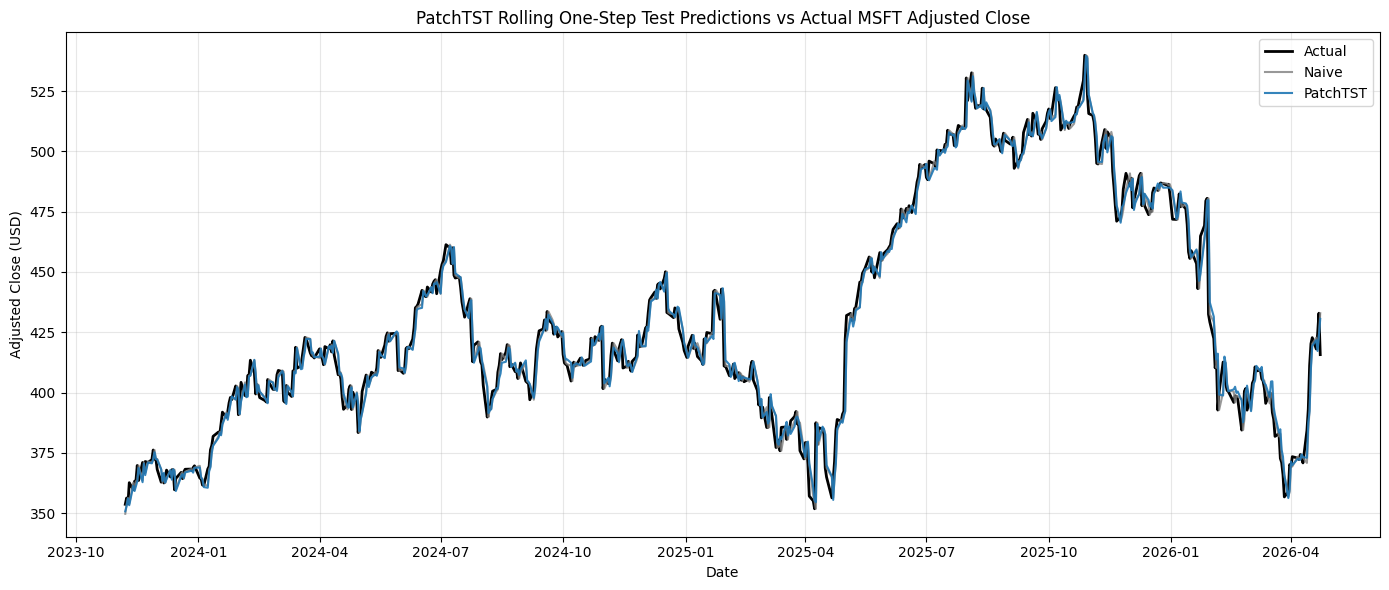

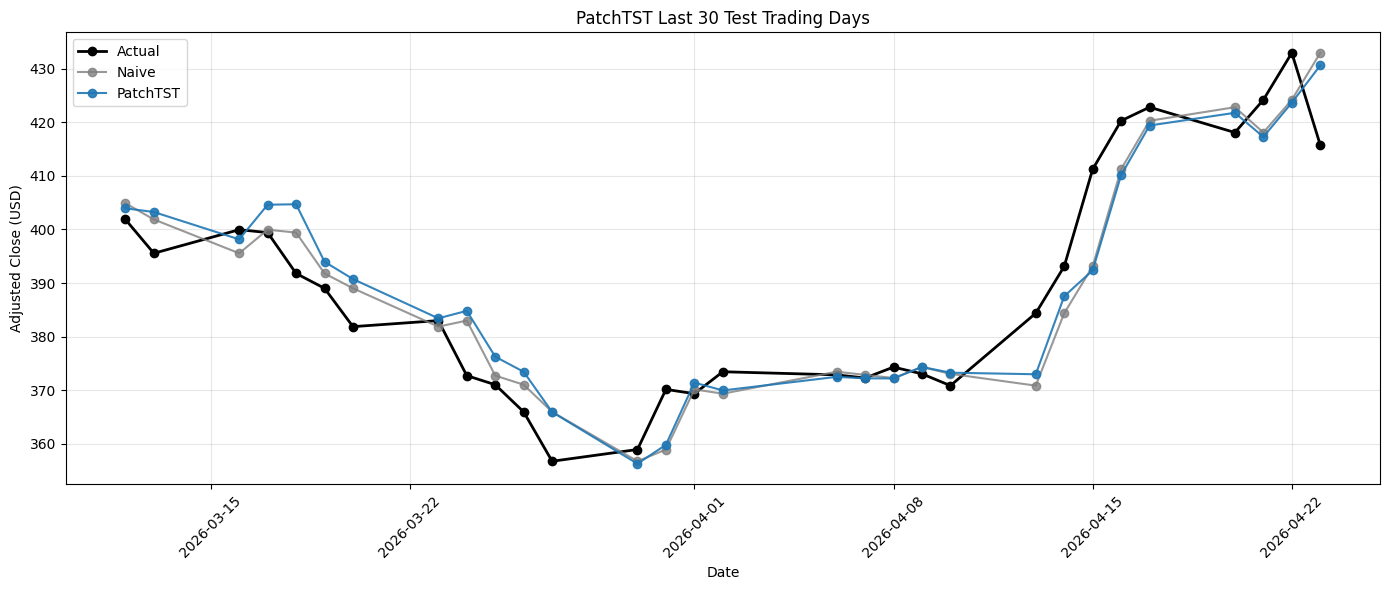

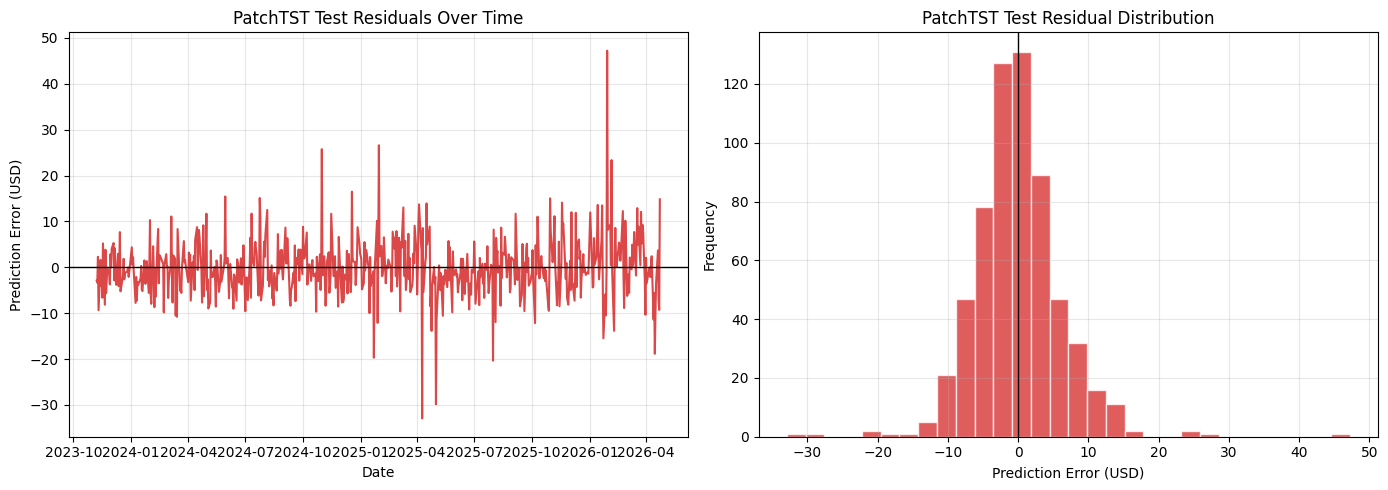

Saved plot paths:
- ../outputs/plots/patchtst_test_predictions.png
- ../outputs/plots/patchtst_zoomed_30d_predictions.png
- ../outputs/plots/patchtst_residuals.png


In [11]:
patchtst_test_plot_df = patchtst_test_predictions_df.copy()
patchtst_test_plot_df["ds"] = pd.to_datetime(patchtst_test_plot_df["ds"])

patchtst_test_plot_path = PLOTS_DIR / "patchtst_test_predictions.png"
plt.figure(figsize=(14, 6))
plt.plot(patchtst_test_plot_df["ds"], patchtst_test_plot_df["Actual"], label="Actual", color="black", linewidth=2)
plt.plot(patchtst_test_plot_df["ds"], patchtst_test_plot_df["Naive"], label="Naive", color="tab:gray", alpha=0.8)
plt.plot(patchtst_test_plot_df["ds"], patchtst_test_plot_df["PatchTST"], label="PatchTST", color="tab:blue", alpha=0.9)
plt.title("PatchTST Rolling One-Step Test Predictions vs Actual MSFT Adjusted Close")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(patchtst_test_plot_path, dpi=150)
plt.show()

zoom_df = patchtst_test_plot_df.tail(30)
patchtst_zoom_plot_path = PLOTS_DIR / "patchtst_zoomed_30d_predictions.png"
plt.figure(figsize=(14, 6))
plt.plot(zoom_df["ds"], zoom_df["Actual"], marker="o", label="Actual", color="black", linewidth=2)
plt.plot(zoom_df["ds"], zoom_df["Naive"], marker="o", label="Naive", color="tab:gray", alpha=0.8)
plt.plot(zoom_df["ds"], zoom_df["PatchTST"], marker="o", label="PatchTST", color="tab:blue", alpha=0.9)
plt.title("PatchTST Last 30 Test Trading Days")
plt.xlabel("Date")
plt.ylabel("Adjusted Close (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(patchtst_zoom_plot_path, dpi=150)
plt.show()

patchtst_residual_plot_path = PLOTS_DIR / "patchtst_residuals.png"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(patchtst_test_plot_df["ds"], patchtst_test_plot_df["PatchTST_Error"], color="tab:red", alpha=0.85)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("PatchTST Test Residuals Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Prediction Error (USD)")
axes[0].grid(True, alpha=0.3)
axes[1].hist(patchtst_test_plot_df["PatchTST_Error"], bins=30, color="tab:red", alpha=0.75, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("PatchTST Test Residual Distribution")
axes[1].set_xlabel("Prediction Error (USD)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(patchtst_residual_plot_path, dpi=150)
plt.show()

print("Saved plot paths:")
for path in [patchtst_test_plot_path, patchtst_zoom_plot_path, patchtst_residual_plot_path]:
    print(f"- {path}")


## Critical interpretation and limitations

This section interprets PatchTST in context rather than assuming that a more complex model must beat a naive baseline.

The discussion checks whether PatchTST beats the naive baseline on validation and test RMSE, whether it is stronger than LSTM/GRU from Notebook 02, whether directional accuracy is close to random or useful, and how the scale shift from Notebook 01 affects generalisation. It also comments on lagging behaviour and explains why these forecasting models should not be interpreted as trading systems.


In [12]:
def metric_value(metrics_df, model, dataset, metric):
    mask = (metrics_df["Model"] == model) & (metrics_df["Dataset"] == dataset)
    return float(metrics_df.loc[mask, metric].iloc[0])

patch_val_rmse = metric_value(patchtst_metrics_df, "PatchTST", "Validation Set", "RMSE")
patch_test_rmse = metric_value(patchtst_metrics_df, "PatchTST", "Test Set", "RMSE")
naive_val_rmse = metric_value(patchtst_metrics_df, "Naive Baseline", "Validation Set", "RMSE")
naive_test_rmse = metric_value(patchtst_metrics_df, "Naive Baseline", "Test Set", "RMSE")
patch_test_direction = metric_value(patchtst_metrics_df, "PatchTST", "Test Set", "Directional_Accuracy")

val_winner = "PatchTST" if patch_val_rmse < naive_val_rmse else "naive baseline"
test_winner = "PatchTST" if patch_test_rmse < naive_test_rmse else "naive baseline"
direction_comment = "close to random" if abs(patch_test_direction - 50) < 5 else "meaningfully away from random"

rnn_context = "Notebook 02 metrics were not found, so this notebook cannot make a numeric LSTM/GRU comparison here."
rnn_metrics_path = TABLES_DIR / "rnn_metrics.csv"
if rnn_metrics_path.exists():
    rnn_metrics_df = pd.read_csv(rnn_metrics_path)
    rnn_test = rnn_metrics_df[rnn_metrics_df["Dataset"] == "Test Set"].set_index("Model")
    parts = []
    for model_name in ["LSTM", "GRU"]:
        if model_name in rnn_test.index:
            rmse = float(rnn_test.loc[model_name, "RMSE"])
            relation = "lower" if patch_test_rmse < rmse else "higher"
            parts.append(f"PatchTST test RMSE is {relation} than {model_name} ({patch_test_rmse:.4f} vs {rmse:.4f}).")
    if parts:
        rnn_context = " ".join(parts)

feature_equivalence_note = ""
if PATCHTST_INPUT_MODE == "Close-only univariate":
    feature_equivalence_note = (
        "Because the OHLCV historical exogenous path failed, PatchTST is not directly feature-equivalent to LSTM/GRU: "
        "LSTM and GRU use multivariate OHLCV windows, while PatchTST uses only the historical Close series. "
        "This makes the comparison not a perfectly controlled architecture-only comparison."
    )
else:
    feature_equivalence_note = "The PatchTST run used OHLCV historical exogenous variables, so its input feature set is closer to the LSTM/GRU OHLCV setup."

interpretation = f"""
### Critical interpretation and limitations

Validation RMSE is `{patch_val_rmse:.4f}` for PatchTST and `{naive_val_rmse:.4f}` for the naive baseline, so the validation winner by RMSE is **{val_winner}**. Test RMSE is `{patch_test_rmse:.4f}` for PatchTST and `{naive_test_rmse:.4f}` for the naive baseline, so the test winner by RMSE is **{test_winner}**. If the naive baseline wins, that result should be reported directly because last-close forecasting is a very strong benchmark for one-step stock-price levels.

{rnn_context}

PatchTST test directional accuracy is `{patch_test_direction:.2f}%`, which is **{direction_comment}**. Directional accuracy near 50% means the model is not providing a reliable up/down signal even if its price-level error is visually small.

Notebook 01 identified a scale shift and non-stationarity: validation and test price levels move outside the training-fitted scaled range. This makes long-horizon generalisation difficult for direct price-level models. In the plots, any persistent under-prediction or delayed following of the actual series should be interpreted as lagging behaviour rather than as a tradable signal.

{feature_equivalence_note}

These results should not be interpreted as a trading system. The notebook does not include transaction costs, slippage, position sizing, risk constraints, live data latency, or a walk-forward trading simulation. It is a forecasting-model comparison for CA2 reporting.
"""

display(Markdown(interpretation))



### Critical interpretation and limitations

Validation RMSE is `5.1492` for PatchTST and `4.9547` for the naive baseline, so the validation winner by RMSE is **naive baseline**. Test RMSE is `6.3617` for PatchTST and `6.2935` for the naive baseline, so the test winner by RMSE is **naive baseline**. If the naive baseline wins, that result should be reported directly because last-close forecasting is a very strong benchmark for one-step stock-price levels.

PatchTST test RMSE is lower than LSTM (6.3617 vs 92.5008). PatchTST test RMSE is lower than GRU (6.3617 vs 34.5774).

PatchTST test directional accuracy is `47.56%`, which is **close to random**. Directional accuracy near 50% means the model is not providing a reliable up/down signal even if its price-level error is visually small.

Notebook 01 identified a scale shift and non-stationarity: validation and test price levels move outside the training-fitted scaled range. This makes long-horizon generalisation difficult for direct price-level models. In the plots, any persistent under-prediction or delayed following of the actual series should be interpreted as lagging behaviour rather than as a tradable signal.

Because the OHLCV historical exogenous path failed, PatchTST is not directly feature-equivalent to LSTM/GRU: LSTM and GRU use multivariate OHLCV windows, while PatchTST uses only the historical Close series. This makes the comparison not a perfectly controlled architecture-only comparison.

These results should not be interpreted as a trading system. The notebook does not include transaction costs, slippage, position sizing, risk constraints, live data latency, or a walk-forward trading simulation. It is a forecasting-model comparison for CA2 reporting.


## Final validation summary

The final cell prints the selected PatchTST configuration, validation/test metrics, leakage checks, saved table paths, and saved plot paths. These artifacts are the PatchTST inputs required by Notebook 04 for the final comparison.


In [13]:
saved_table_paths = [
    TABLES_DIR / "patchtst_date_index_mapping.csv",
    TABLES_DIR / "patchtst_tuning_results.csv",
    TABLES_DIR / "patchtst_val_predictions.csv",
    TABLES_DIR / "patchtst_test_predictions.csv",
    TABLES_DIR / "patchtst_predictions.csv",
    TABLES_DIR / "patchtst_metrics.csv",
    TABLES_DIR / "patchtst_selected_config.csv",
]
saved_plot_paths = [
    PLOTS_DIR / "patchtst_test_predictions.png",
    PLOTS_DIR / "patchtst_zoomed_30d_predictions.png",
    PLOTS_DIR / "patchtst_residuals.png",
]

selected_candidate_name = selected_config["CandidateName"]
better_test_rmse = "PatchTST" if patch_test_rmse < naive_test_rmse else "Naive Baseline"

print("Notebook 03 completed successfully")
print(f"Downloaded data shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Downloaded date range: {df.index[0].date()} to {df.index[-1].date()}")
print("Raw train/validation/test ranges and row counts:")
print(f"- Train: {len(train_df)} rows, {train_df.index[0].date()} to {train_df.index[-1].date()}")
print(f"- Validation: {len(val_df)} rows, {val_df.index[0].date()} to {val_df.index[-1].date()}")
print(f"- Test: {len(test_df)} rows, {test_df.index[0].date()} to {test_df.index[-1].date()}")
print(f"PatchTST input mode used: {PATCHTST_INPUT_MODE}")
print(f"Input mode note: {input_mode_note}")
print(f"forecasting_protocol: {FORECASTING_PROTOCOL}")
print(f"training_protocol: {TRAINING_PROTOCOL}")
print(f"Selected PatchTST candidate: {selected_candidate_name}")
print(f"Validation RMSE: {patch_val_rmse:.4f}")
print(f"Test RMSE: {patch_test_rmse:.4f}")
print(f"Better test RMSE: {better_test_rmse}")
print(f"Test Directional_Accuracy: {patch_test_direction:.2f}%")
print("Leakage checks:")
print(f"- Validation cutoff convention: {val_leakage_summary['cutoff_convention_note']}")
print(f"- Test cutoff convention: {test_leakage_summary['cutoff_convention_note']}")
print("Saved table paths:")
for path in saved_table_paths:
    print(f"- {path}")
print("Saved plot paths:")
for path in saved_plot_paths:
    print(f"- {path}")
print("Confirmation: Notebook 01, 02, and 04 were not edited or run as part of this Notebook 03 execution.")


Notebook 03 completed successfully
Downloaded data shape: 4101 rows x 5 columns
Downloaded date range: 2010-01-04 to 2026-04-23
Raw train/validation/test ranges and row counts:
- Train: 2870 rows, 2010-01-04 to 2021-05-27
- Validation: 615 rows, 2021-05-28 to 2023-11-06
- Test: 616 rows, 2023-11-07 to 2026-04-23
PatchTST input mode used: Close-only univariate
Input mode note: OHLCV historical exogenous path failed; fell back to Close-only. Reason: Exception: PatchTST does not support historical exogenous variables.
forecasting_protocol: rolling_one_step_ahead
training_protocol: selected_on_train_to_val_then_refit_train_val_for_test
Selected PatchTST candidate: C
Validation RMSE: 5.1492
Test RMSE: 6.3617
Better test RMSE: Naive Baseline
Test Directional_Accuracy: 47.56%
Leakage checks:
- Validation cutoff convention: NeuralForecast returned target_step - cutoff_step values: [1]. For this h=1 run, cutoff_step is the final observed trading step before the target step.
- Test cutoff conven

## Notebook 03 summary

This notebook produced PatchTST validation and test predictions using the same MSFT target dates as the previous notebooks. It also saved tuning results, selected configuration details, leakage/alignment evidence, metrics, and diagnostic plots.

Notebook 04 uses `patchtst_test_predictions.csv` and `patchtst_metrics.csv` together with the RNN outputs to compare all models on the same test dates.
